In [1]:
import torch
import numpy as np

### Autoencoders 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim) 
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)       
        x_hat = self.decoder(z)
        return x_hat, z

# The loss is purely reconstruction (e.g., Mean Squared Error)
# loss = F.mse_loss(x_hat, x)

## Variational Autoencoders (VAEs)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.shared_enc = nn.Sequential(nn.Linear(input_dim, 128), nn.ReLU())
        
        # Instead of one output, the encoder branches into two -> for the probabaility distribution 
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def encode(self, x):
        h = self.shared_enc(x)
        return self.fc_mu(h), self.fc_logvar(h) # Returns mu and log variance

    def reparameterize(self, mu, logvar): 

        # standard deviation
        std = torch.exp(0.5 * logvar) 

        # Sample random noise epsilon
        eps = torch.randn_like(std)

        # Shift and scale
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar) # Sample z from the distribution
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

def vae_loss(x_hat, x, mu, logvar):

    # 1. Reconstruction Loss
    recon_loss = F.mse_loss(x_hat, x, reduction='sum')

    # 2. KL Divergence penalty
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_div

## Conditional Variational Autoencoder

In [ ]:
class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim):
        super().__init__()

        # Encoder input -> (data + condition)
        self.shared_enc = nn.Sequential(nn.Linear(input_dim + cond_dim, 128), nn.ReLU())
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Decoder input -> (latent sample + condition)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def encode(self, x, c):
        # Concatenate x and c along the feature dimension
        x_c = torch.cat([x, c], dim=-1) 
        h = self.shared_enc(x_c)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        
        # Concatenate sampled z and condition c
        z_c = torch.cat([z, c], dim=-1)
        x_hat = self.decoder(z_c)
        return x_hat, mu, logvar

# The loss function remains mathematically identical to the VAE loss.
# The network geometry does the conditional sampling inherently while training

## Comparison: AE vs VAE vs CVAE

**3-cluster Gaussian dataset** (2D input, 2D latent) so the latent space is directly plottable.

| Model | Latent space | Can sample? | Conditioned? |
|-------|-------------|-------------|--------------|
| AE    | arbitrary points | ✗ | ✗ |
| VAE   | smooth distribution | ✓ (unconditional) | ✗ |
| CVAE  | smooth, per-class distribution | ✓ (conditional) | ✓ |

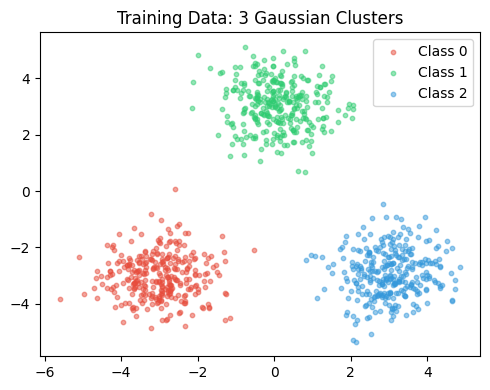

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

means  = [[-3, -3], [0, 3], [3, -3]]
n_per  = 300
COLORS = ['#e74c3c', '#2ecc71', '#3498db']

X_np = np.concatenate(
    [np.random.randn(n_per, 2) * 0.8 + m for m in means]
).astype(np.float32)
y_np = np.concatenate([np.full(n_per, i) for i in range(3)]).astype(int)

X = torch.tensor(X_np)          # float32
y = torch.tensor(y_np)

N_CLASSES = 3
C = torch.zeros(len(y), N_CLASSES)  # float32
C[torch.arange(len(y)), y] = 1.0

fig, ax = plt.subplots(figsize=(5, 4))
for i in range(N_CLASSES):
    mask = y_np == i
    ax.scatter(X_np[mask, 0], X_np[mask, 1], s=10, alpha=0.5, c=COLORS[i], label=f'Class {i}')
ax.set_title('Training Data: 3 Gaussian Clusters')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch.optim as optim

INPUT_DIM  = 2
LATENT_DIM = 2
COND_DIM   = N_CLASSES
LR         = 1e-3
EPOCHS     = 800
BATCH      = 128

ae   = Autoencoder(INPUT_DIM, LATENT_DIM)
vae  = VAE(INPUT_DIM, LATENT_DIM)
cvae = CVAE(INPUT_DIM, COND_DIM, LATENT_DIM)

opt_ae   = optim.Adam(ae.parameters(),   lr=LR)
opt_vae  = optim.Adam(vae.parameters(),  lr=LR)
opt_cvae = optim.Adam(cvae.parameters(), lr=LR)

loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X, C), batch_size=BATCH, shuffle=True
)

history = {'AE': [], 'VAE': [], 'CVAE': []}

for epoch in range(EPOCHS):
    ae_ep = vae_ep = cvae_ep = 0.0
    for xb, cb in loader:

        #  AE
        opt_ae.zero_grad()
        x_hat, _ = ae(xb)
        loss = F.mse_loss(x_hat, xb)
        loss.backward(); opt_ae.step()
        ae_ep += loss.item()

        # VAE
        opt_vae.zero_grad()
        x_hat, mu, logvar = vae(xb)
        loss = vae_loss(x_hat, xb, mu, logvar) / len(xb)
        loss.backward(); opt_vae.step()
        vae_ep += loss.item()

        # CVAE
        opt_cvae.zero_grad()
        x_hat, mu, logvar = cvae(xb, cb)
        loss = vae_loss(x_hat, xb, mu, logvar) / len(xb)
        loss.backward(); opt_cvae.step()
        cvae_ep += loss.item()

    history['AE'].append(ae_ep   / len(loader))
    history['VAE'].append(vae_ep  / len(loader))
    history['CVAE'].append(cvae_ep / len(loader))

print("Training complete.")

Training complete.


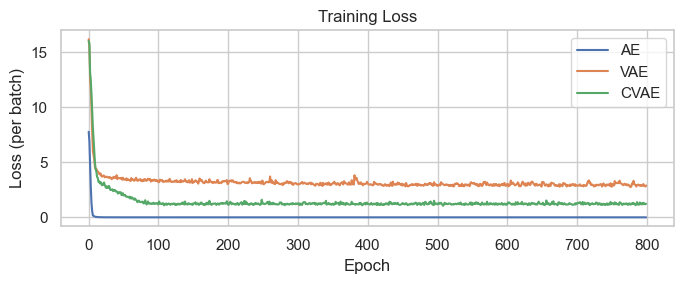

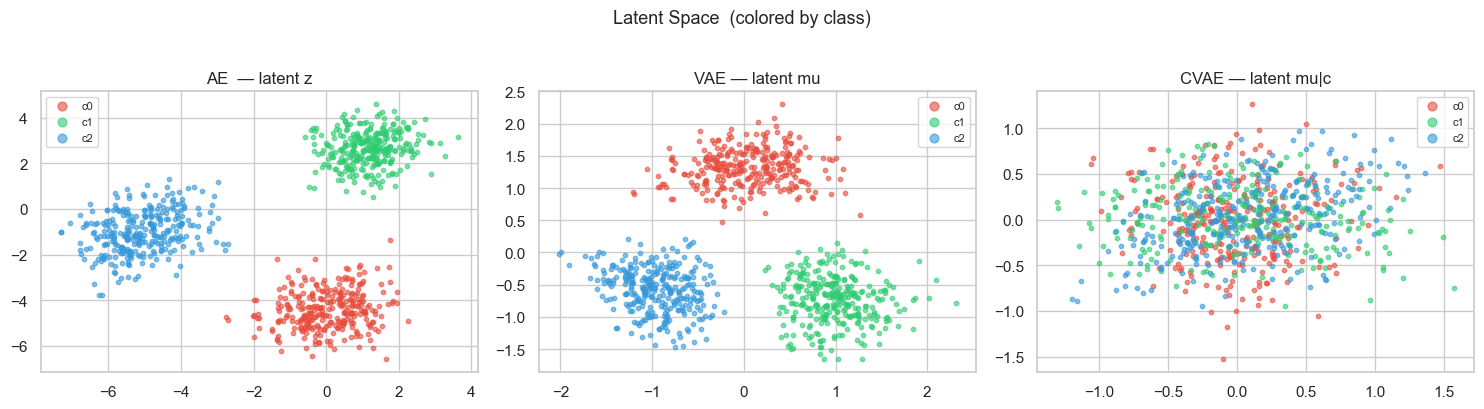

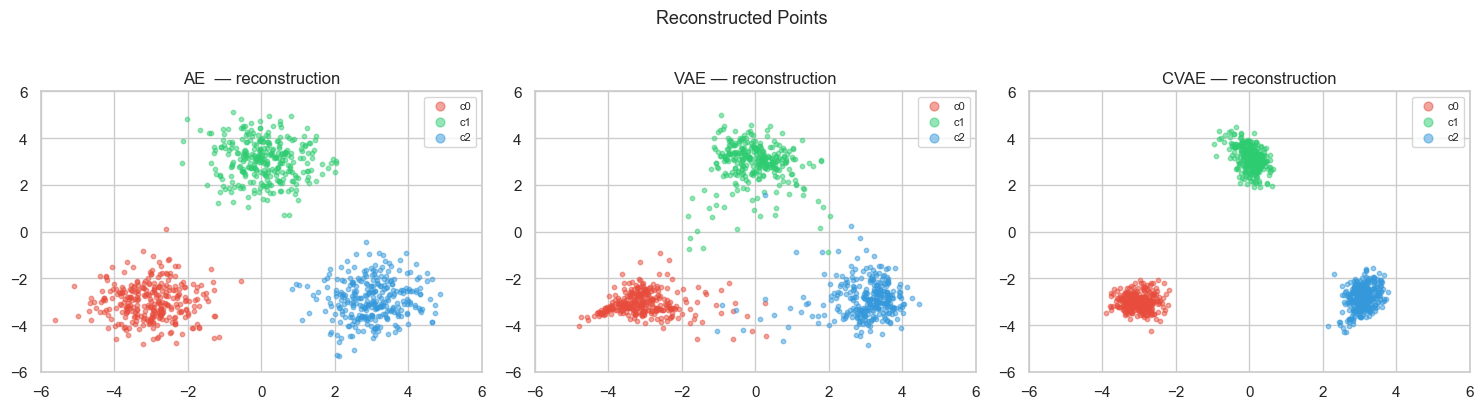

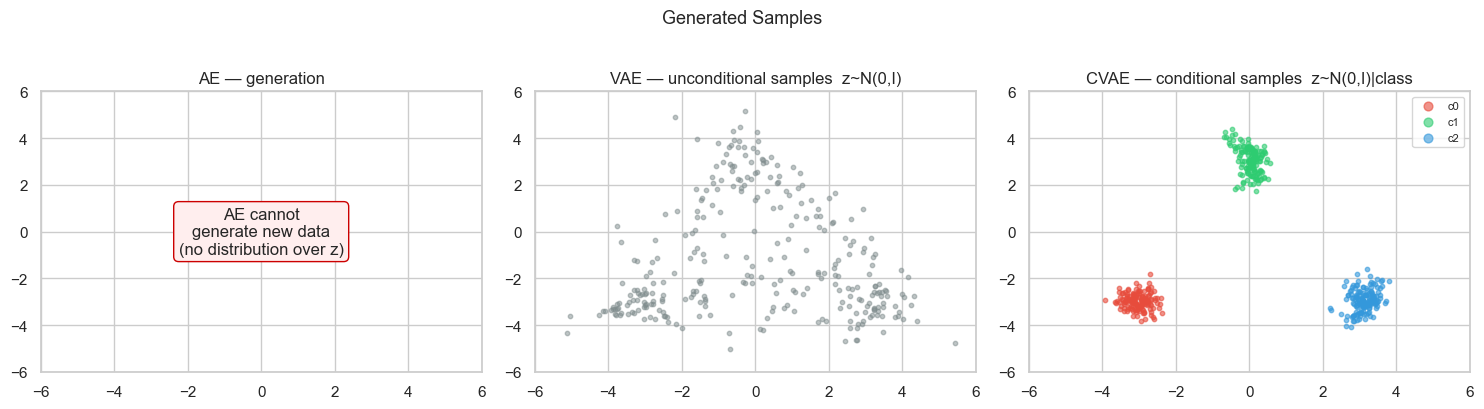

In [17]:
sns.set_theme(style='whitegrid')

# Loss curves 
fig, ax = plt.subplots(figsize=(7, 3))
for name, ls in history.items():
    ax.plot(ls, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (per batch)')
ax.set_title('Training Loss'); ax.legend()
plt.tight_layout(); plt.show()

# Single forward pass for latent space + reconstructions 
with torch.no_grad():
    rec_ae,  z_ae         = ae(X)
    rec_vae,  mu_vae,  _  = vae(X)
    rec_cvae, mu_cvae, _  = cvae(X, C)

# Latent space 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, z, title in zip(axes,
                        [z_ae, mu_vae, mu_cvae],
                        ['AE  — latent z', 'VAE — latent mu', 'CVAE — latent mu|c']):
    z_np = z.numpy()
    for i in range(N_CLASSES):
        m = y_np == i
        ax.scatter(z_np[m, 0], z_np[m, 1], s=10, alpha=0.6, c=COLORS[i], label=f'c{i}')
    ax.set_title(title); ax.legend(markerscale=2, fontsize=8)
plt.suptitle('Latent Space  (colored by class)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# Reconstructions 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, rec, title in zip(axes,
                          [rec_ae, rec_vae, rec_cvae],
                          ['AE  — reconstruction', 'VAE — reconstruction', 'CVAE — reconstruction']):
    r = rec.numpy()
    for i in range(N_CLASSES):
        m = y_np == i
        ax.scatter(r[m, 0], r[m, 1], s=10, alpha=0.5, c=COLORS[i], label=f'c{i}')
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_title(title); ax.legend(markerscale=2, fontsize=8)
plt.suptitle('Reconstructed Points', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# Generating samples
with torch.no_grad():
    gen_vae = vae.decoder(torch.randn(300, LATENT_DIM)).numpy()

    gen_cvae = []
    for i in range(N_CLASSES):
        c_vec  = torch.zeros(150, N_CLASSES); c_vec[:, i] = 1.0
        z_c_in = torch.cat([torch.randn(150, LATENT_DIM), c_vec], dim=-1)
        gen_cvae.append(cvae.decoder(z_c_in).numpy())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].text(0.5, 0.5,
             'AE cannot\ngenerate new data\n(no distribution over z)',
             ha='center', va='center', fontsize=12, transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='#fee', edgecolor='#c00'))
axes[0].set_title('AE — generation'); axes[0].set_xlim(-6, 6); axes[0].set_ylim(-6, 6)

axes[1].scatter(gen_vae[:, 0], gen_vae[:, 1], s=10, alpha=0.5, c='#7f8c8d')
axes[1].set_title('VAE — unconditional samples  z~N(0,I)')
axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6)

for i, pts in enumerate(gen_cvae):
    axes[2].scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.6, c=COLORS[i], label=f'c{i}')
axes[2].set_title('CVAE — conditional samples  z~N(0,I)|class')
axes[2].set_xlim(-6, 6); axes[2].set_ylim(-6, 6); axes[2].legend(markerscale=2, fontsize=8)

plt.suptitle('Generated Samples', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()
